In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [14]:
df = pd.read_csv("data/processed/usnd_cleaned.csv")
df.head(5)

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program,year,month
0,DR-1,Disaster,1953-05-02,GA,Unknown,Tornado,Tornado,05/02/1953,05/02/1953,Yes,No,Yes,Yes,1953,5
1,DR-2,Disaster,1953-05-15,TX,Unknown,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,Yes,No,Yes,Yes,1953,5
2,DR-3,Disaster,1953-05-29,LA,Unknown,Flood,Flood,05/29/1953,05/29/1953,Yes,No,Yes,Yes,1953,5
3,DR-4,Disaster,1953-06-02,MI,Unknown,Tornado,Tornado,06/02/1953,06/02/1953,Yes,No,Yes,Yes,1953,6
4,DR-5,Disaster,1953-06-06,MT,Unknown,Flood,Floods,06/06/1953,06/06/1953,Yes,No,Yes,Yes,1953,6


In [15]:
print(df.isnull().sum())

Declaration Number                  0
Declaration Type                    0
Declaration Date                    0
State                               0
County                              0
Disaster Type                       0
Disaster Title                      0
Start Date                          0
End Date                            0
Individual Assistance Program       0
Individuals & Households Program    0
Public Assistance Program           0
Hazard Mitigation Program           0
year                                0
month                               0
dtype: int64


In [16]:
print("Number of states:", df["State"].nunique())
print("Incident Types:", df["Disaster Type"].unique())

Number of states: 59
Incident Types: <StringArray>
[        'Tornado',           'Flood',            'Fire',           'Other',
      'Earthquake',       'Hurricane',         'Volcano',           'Storm',
        'Chemical',         'Typhoon',         'Drought', 'Dam/Levee Break',
            'Snow',             'Ice',          'Winter',           'Water',
   'Mud/Landslide',     'Human Cause',       'Terrorism',         'Tsunami']
Length: 20, dtype: str


In [17]:
df.columns = df.columns.str.strip()
state_counts = df.groupby("State").size().sort_values(ascending=False)
state_counts_df = state_counts.reset_index()
state_counts_df.columns = ["State", "disaster_count"]
print(state_counts_df.head(10))

  State  disaster_count
0    TX            3842
1    MO            2263
2    KY            2026
3    VA            1982
4    OK            1882
5    FL            1512
6    IA            1471
7    GA            1406
8    LA            1393
9    NC            1312


In [18]:

state_data = df['State'].value_counts().reset_index()
state_data.columns = ['State', 'Count']
fig = px.choropleth(
    state_data,
    locations='State',
    locationmode="USA-states",
    color='Count',
    scope="usa",
    title="Disaster Declarations by State"
)
fig.show()

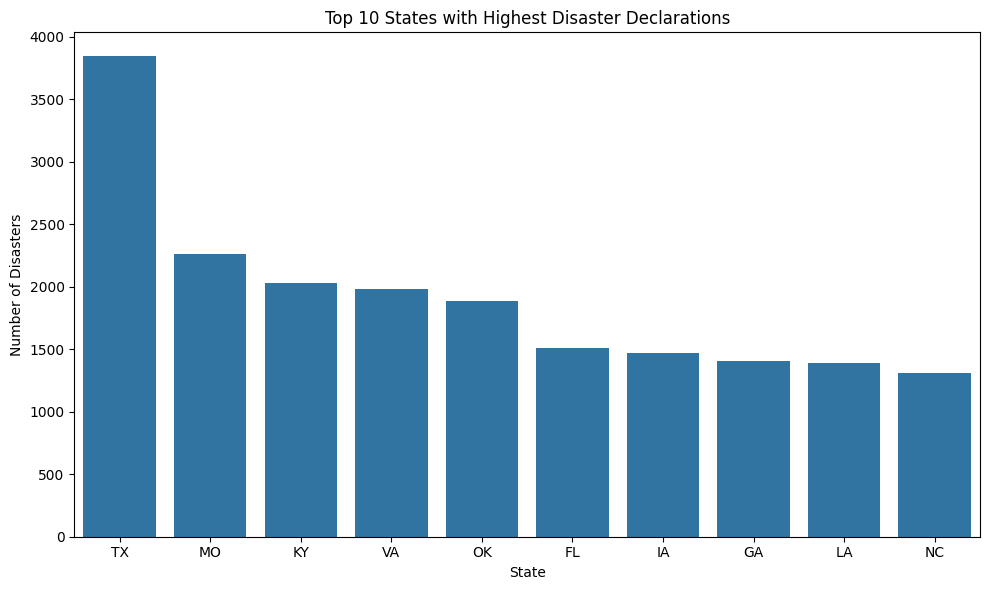

In [19]:
top_states = state_counts.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")
plt.tight_layout()
plt.show()

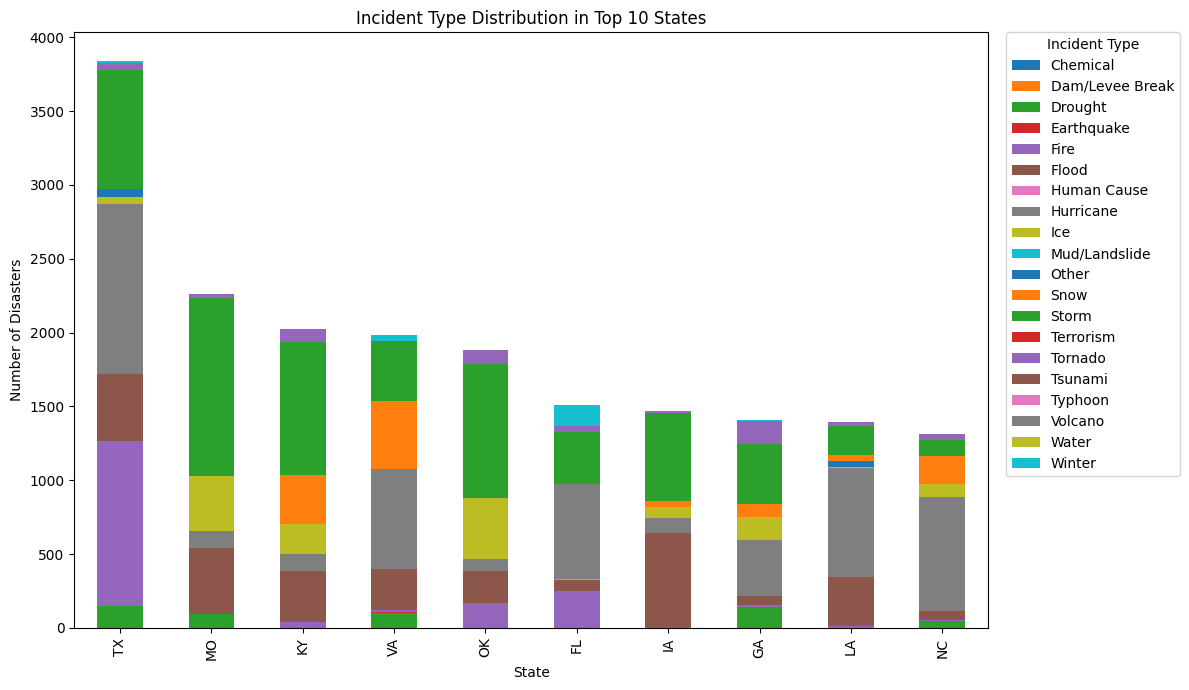

In [20]:

incident_state = pd.crosstab(df['State'], df['Disaster Type'])
state_counts = incident_state.sum(axis=1).sort_values(ascending=False)
top10_states = incident_state.loc[state_counts.head(10).index]
top10_states.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)
plt.title("Incident Type Distribution in Top 10 States")
plt.xlabel("State")
plt.ylabel("Number of Disasters")
plt.legend(title="Incident Type",
           bbox_to_anchor=(1.02, 1),
           loc="upper left",
           borderaxespad=0)
plt.tight_layout()
plt.show()

In [21]:
flood_df = df[df["Disaster Type"] == "Flood"]
flood_counts = flood_df.groupby("State").size().reset_index(name="count")
import plotly.express as px
fig = px.choropleth(
    flood_counts,
    locations="State",
    locationmode="USA-states",
    color="count",
    scope="usa",
    color_continuous_scale="Blues",
    title="Flood Disaster Hotspots in the United States"
)
fig.show()